# Modeling V7 — Corrected Features, 3-Way Ablation, Frozen-Test-Set Scoring

## 1. Load Dev Data & Filter Predictor Population

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_with_features-3.csv")

valid_df = df[df["valid"] == 1].copy() if "valid" in df.columns else df.copy()
predictor_df = valid_df[valid_df["revision_called"] == 1].copy()

print(f"Total Rows: {len(df)}")
print(f"Valid Rows: {len(valid_df)}")
print(f"Predictor Population (Disagreements Only): {len(predictor_df)}")
print(f"Beneficial (HELPED) in predictor population: {int(predictor_df['beneficial'].sum())} "
      f"({predictor_df['beneficial'].mean():.1%})")

Total Rows: 2000
Valid Rows: 1981
Predictor Population (Disagreements Only): 293
Beneficial (HELPED) in predictor population: 58 (19.8%)


## 2. Feature Selection and Variance Check

In [2]:
candidate_features = [
    col for col in predictor_df.columns
    if col.startswith((
        "answer_distance", "hedging_count", "error_desc_length",
        "critique_tokens", "solver_tokens", "critic_independent_tokens",
        "direction_", "proposed_answer_differs",
    ))
]

feature_variances = predictor_df[candidate_features].var(numeric_only=True)
nonzero_var = feature_variances[feature_variances > 0].index.tolist()

near_constant_cols = [
    c for c in nonzero_var
    if predictor_df[c].value_counts(normalize=True).iloc[0] >= 0.95
]
print("Near-constant columns dropped:", near_constant_cols)

active_features = [
    "answer_distance_log1p", "answer_distance_norm", "answer_distance_signed_log1p",
    "hedging_count", "error_desc_length",
    "direction_llama_solver_qwen_critic", "direction_qwen_solver_llama_critic",
]
assert set(near_constant_cols).isdisjoint(active_features)

direction_cols = ["direction_llama_solver_qwen_critic", "direction_qwen_solver_llama_critic"]
critique_cols = [c for c in active_features if c not in direction_cols]
print("Active features:", active_features)

Near-constant columns dropped: ['proposed_answer_differs']
Active features: ['answer_distance_log1p', 'answer_distance_norm', 'answer_distance_signed_log1p', 'hedging_count', 'error_desc_length', 'direction_llama_solver_qwen_critic', 'direction_qwen_solver_llama_critic']


## 3. Cross-Validated Logistic Regression (Dev Set, StratifiedGroupKFold on `question_id`)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix
)


def evaluate_logistic_cv(X, y, groups, n_splits=5, seed=42):
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    metrics = {"precision": [], "recall": [], "f1": [], "pr_auc": [], "roc_auc": [], "tn": [], "fp": [], "fn": [], "tp": []}
    oof_preds = np.zeros(len(X)); oof_probs = np.zeros(len(X))

    for train_idx, val_idx in sgkf.split(X, y, groups):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr); X_va_s = scaler.transform(X_va)
        model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=seed)
        model.fit(X_tr_s, y_tr)
        probs = model.predict_proba(X_va_s)[:, 1]
        preds = (probs >= 0.5).astype(int)
        oof_probs[val_idx] = probs; oof_preds[val_idx] = preds
        metrics["precision"].append(precision_score(y_va, preds, zero_division=0))
        metrics["recall"].append(recall_score(y_va, preds, zero_division=0))
        metrics["f1"].append(f1_score(y_va, preds, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y_va, preds, labels=[0, 1]).ravel()
        metrics["tn"].append(tn); metrics["fp"].append(fp); metrics["fn"].append(fn); metrics["tp"].append(tp)
        if len(np.unique(y_va)) > 1:
            metrics["pr_auc"].append(average_precision_score(y_va, probs))
            metrics["roc_auc"].append(roc_auc_score(y_va, probs))

    summary = {k: f"{np.mean(v):.3f} \u00b1 {np.std(v):.3f}" for k, v in metrics.items()}
    return summary, oof_preds, oof_probs


X = predictor_df[active_features]
y = predictor_df["beneficial"].astype(int)
groups = predictor_df["question_id"]

cv_summary, oof_preds, oof_probs = evaluate_logistic_cv(X, y, groups, n_splits=5)

print("--- Dev-Set CV Predictor Performance (All Features) ---")
for metric in ["precision", "recall", "f1", "pr_auc", "roc_auc"]:
    print(f"{metric.upper():<10}: {cv_summary[metric]}")
agg_cm = confusion_matrix(y, oof_preds, labels=[0, 1])
print("\nAggregated OOF Confusion Matrix:")
print(pd.DataFrame(agg_cm, columns=["Pred: 0", "Pred: 1"], index=["Actual: 0", "Actual: 1"]))

--- Dev-Set CV Predictor Performance (All Features) ---
PRECISION : 0.286 ± 0.024
RECALL    : 0.706 ± 0.070
F1        : 0.407 ± 0.035
PR_AUC    : 0.378 ± 0.081
ROC_AUC   : 0.637 ± 0.046

Aggregated OOF Confusion Matrix:
           Pred: 0  Pred: 1
Actual: 0      133      102
Actual: 1       17       41


## 4. Three-Way Ablation: Direction Only / Critique Features Only / All

In [4]:
ablation_sets = {
    "Direction Only": direction_cols,
    "Critique Features Only": critique_cols,
    "All (Combined)": active_features,
}
ablation_results = []
for name, cols in ablation_sets.items():
    res, _, _ = evaluate_logistic_cv(predictor_df[cols], y, groups, n_splits=5)
    ablation_results.append({
        "Feature Subset": name, "Num Features": len(cols),
        "Precision": res["precision"], "Recall": res["recall"],
        "F1 Score": res["f1"], "PR-AUC": res["pr_auc"], "ROC-AUC": res["roc_auc"],
    })
ablation_df = pd.DataFrame(ablation_results)
print("--- 3-Way Feature Ablation (Dev Set) ---")
ablation_df

--- 3-Way Feature Ablation (Dev Set) ---


,Feature Subset,Num Features,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
0,Direction Only,2,0.290 ± 0.023,0.706 ± 0.070,0.411 ± 0.034,0.264 ± 0.025,0.640 ± 0.036
1,Critique Features Only,5,0.209 ± 0.040,0.485 ± 0.120,0.290 ± 0.055,0.330 ± 0.075,0.562 ± 0.046
2,All (Combined),7,0.286 ± 0.024,0.706 ± 0.070,0.407 ± 0.035,0.378 ± 0.081,0.637 ± 0.046


## 5. Fit Final Model on the Full Dev Set

In [5]:
final_scaler = StandardScaler().fit(predictor_df[active_features])
X_full_scaled = final_scaler.transform(predictor_df[active_features])
final_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
final_model.fit(X_full_scaled, y)
print("Final model fit on", len(predictor_df), "dev disagreement rows.")

Final model fit on 293 dev disagreement rows.


## 6. Load the Frozen Test Set 

In [6]:
test_df = pd.read_csv("test_dataset_with_features.csv")

test_valid = test_df[test_df["valid"] == 1].copy()
test_predictor = test_valid[test_valid["revision_called"] == 1].copy()

print(f"Test valid rows: {len(test_valid)}")
print(f"Test disagreement (predictor) rows: {len(test_predictor)}")
print(f"Test transitions:\n{test_valid['transition'].value_counts()}")

Test valid rows: 298
Test disagreement (predictor) rows: 37
Test transitions:
transition
STABLE-CORRECT    265
STABLE-WRONG       23
HELPED              5
HURT                5
Name: count, dtype: int64


## 7. Score the 5 Policies on the Frozen Test Set — ONE TIME ONLY

In [7]:
test_X_scaled = final_scaler.transform(test_predictor[active_features])
test_predictor["predicted_beneficial"] = final_model.predict(test_X_scaled)

test_eval = test_valid.copy()
test_eval["predicted_beneficial"] = 0
test_eval.loc[test_predictor.index, "predicted_beneficial"] = test_predictor["predicted_beneficial"]

def get_policy_final_answer(row, policy_name):
    if row["revision_called"] == 0:
        return str(row["solver_answer"]).strip()
    if policy_name == "1_never_accept":
        return str(row["solver_answer"]).strip()
    elif policy_name == "2_adopt_critic":
        return str(row["critic_proposed_answer"]).strip()
    elif policy_name == "3_always_accept":
        return str(row["revised_answer"]).strip()
    elif policy_name == "4_learned_policy":
        return str(row["revised_answer"]).strip() if row["predicted_beneficial"] == 1 else str(row["solver_answer"]).strip()
    elif policy_name == "5_oracle":
        return str(row["revised_answer"]).strip() if row["transition"] == "HELPED" else str(row["solver_answer"]).strip()

def check_correctness(final_ans, gold_ans):
    try:
        return float(final_ans) == float(gold_ans)
    except Exception:
        return str(final_ans).strip() == str(gold_ans).strip()

policies = ["1_never_accept", "2_adopt_critic", "3_always_accept", "4_learned_policy", "5_oracle"]
test_policy_accuracies = {}
for pol in policies:
    correct = test_eval.apply(lambda r: check_correctness(get_policy_final_answer(r, pol), r["gold_answer"]), axis=1).sum()
    test_policy_accuracies[pol] = correct / len(test_eval)

print(f"--- FROZEN TEST SET Policy Accuracy (n = {len(test_eval)}) ---")
for pol, acc in test_policy_accuracies.items():
    print(f"{pol:<20}: {acc:.2%}")

learned_correct_on_disagreement = test_predictor.apply(
    lambda r: check_correctness(get_policy_final_answer(r, "4_learned_policy"), r["gold_answer"]), axis=1
)
print(f"\nLearned policy on the {len(test_predictor)} disagreement rows only: "
      f"{learned_correct_on_disagreement.mean():.2%} correct "
      f"({int(test_predictor['beneficial'].sum())} true HELPED, "
      f"{int(test_predictor['predicted_beneficial'].sum())} predicted beneficial)")

--- FROZEN TEST SET Policy Accuracy (n = 298) ---
1_never_accept      : 90.60%
2_adopt_critic      : 90.27%
3_always_accept     : 90.60%
4_learned_policy    : 90.94%
5_oracle            : 92.28%

Learned policy on the 37 disagreement rows only: 40.54% correct (5 true HELPED, 18 predicted beneficial)


## 8. Save Artifacts

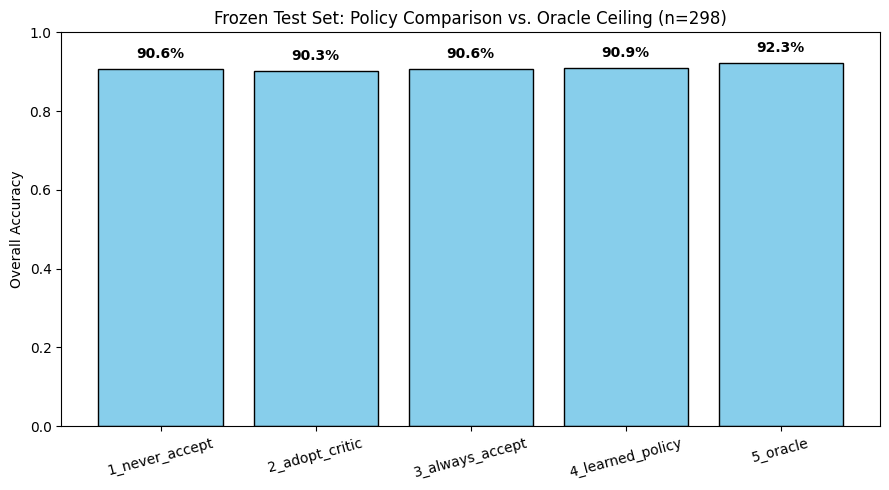

Saved: results/ablation_3way.csv, results/test_policy_comparison.csv, results/modeling_v5_metrics.json, figures/test_policy_vs_oracle.png


In [8]:
import matplotlib.pyplot as plt
import json
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(9, 5))
policy_series = pd.Series(test_policy_accuracies)
bars = plt.bar(policy_series.index, policy_series.values, color="skyblue", edgecolor="black")
plt.ylabel("Overall Accuracy")
plt.title("Frozen Test Set: Policy Comparison vs. Oracle Ceiling (n=298)")
plt.ylim(0, 1.0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.1%}", ha="center", va="bottom", fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/test_policy_vs_oracle.png")
plt.show()

ablation_df.to_csv("results/ablation_3way.csv", index=False)
pd.DataFrame(list(test_policy_accuracies.items()), columns=["Policy", "Accuracy"]).to_csv("results/test_policy_comparison.csv", index=False)

summary_artifact = {
    "dev_cv_metrics_all_features": cv_summary,
    "test_policy_accuracies": test_policy_accuracies,
    "test_set_n": len(test_eval),
    "test_disagreement_n": len(test_predictor),
    "notes": "Test set features computed by the same feature-engineering pipeline as the dev set (test_dataset_with_features.csv).",
}
with open("results/modeling_v5_metrics.json", "w") as f:
    json.dump(summary_artifact, f, indent=2)

print("Saved: results/ablation_3way.csv, results/test_policy_comparison.csv, results/modeling_v5_metrics.json, figures/test_policy_vs_oracle.png")